# Hidden-Entrepreneur Detection from Consumer Card Transactions

**Goal.** Classify each card as *consumer* (0) vs *business / hidden entrepreneur* (1) from
transaction behavior, then score the consumer pool to surface clients who behave like
businesses and should move to business products (POS acquiring, working-capital loans,
payroll, cash management, bookkeeping).

**Framing.** Train on the two labeled pools (`business=1`, `consumer=0`) aggregated to
**one row per card**, then score consumers **out-of-fold** to find hidden entrepreneurs.
The consumer pool is a *contaminated* negative class (it may contain the very positives we
hunt), so ranking & precision@top-K matter more than headline accuracy.

### Headline findings (read first)
1. **No single-feature label leak** after dropping `card_tier` (business is 100% `"Business"`).
   Raw `mcc`/`merchant_id` are **not** one-hot encoded (class-exclusive values are coverage
   artifacts); the B2B basket is domain-curated and `5122` was removed (business-exclusive here).
2. **All models reach ROC-AUC ≈ 1.00** (even Logistic Regression). This is a property of the
   **synthetic data** — the per-class behavioral generators barely overlap. *Real-world AUC
   would be lower.* The durable value is the feature interpretation + the ranking method.
3. **The synthetic consumer pool contains essentially no embedded hidden entrepreneurs:**
   out-of-fold `P(business)` is ~0 for 99.9% of consumers; ~11 score business-like. Those few
   form the actionable list. On *real* bank data this same pipeline would surface far more.

*Reproducibility:* a single `SEED` in `config.py` drives split / CV / models. Heavy logic lives
in `features.py`, `train_eval.py`, `mdq_utils.py` so cells stay short. See `README.md` to run.

## 00 · Setup & reproducibility

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, gc
import shap
from IPython.display import display
from sklearn.model_selection import train_test_split

from config import (SEED, LEAD_THR, TEST_SIZE, ID_COL, LABEL_COL, B2B_MCC,
                    CONSUMER_FILE, BUSINESS_FILE, MERCHANT_FILE, FEAT_FILE)
from features import load_labeled, build_card_features, LEAKY_OR_EXCLUDED
from train_eval import make_logreg, make_lgbm, make_rf
from mdq_utils import (ranking_metrics, metrics_at_threshold, tune_thresholds,
                       oof_proba, shap_positive_values, plot_confusion)

np.random.seed(SEED)
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (8, 4); plt.rcParams["figure.dpi"] = 110
print("setup ok | SEED =", SEED)

setup ok | SEED = 42


C:\Users\olzha\OneDrive\Рабочий_стол\MDQ\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 01 · Load & schema audit
Confirm the real column names/dtypes (snake_case) before any feature code.

In [2]:
consumer  = pd.read_parquet(CONSUMER_FILE)
business  = pd.read_parquet(BUSINESS_FILE)
merchants = pd.read_parquet(MERCHANT_FILE)
print("consumer", consumer.shape, "| business", business.shape, "| merchants", merchants.shape)
display(consumer.dtypes.to_frame("dtype"))
display(consumer.head(3))

consumer (9832487, 12) | business (2997593, 12) | merchants (2165, 5)


,dtype
transaction_date,object
transaction_timestamp,datetime64[ms]
transaction_amount_kzt,int64
mcc,str
merchant_id,str
channel,str
bank_name,str
country,str
card_number,str
card_tier,str


,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring
0,2025-10-01,2025-10-01 00:04:00,4788,4814,MER_000064,online,Alatau City Bank,Kazakhstan,5263907968824596,Standard,False,True
1,2025-10-01,2025-10-01 00:10:00,5240,4814,MER_000063,online,Bank RBK,Kazakhstan,5119023663984986,Standard,False,True
2,2025-10-01,2025-10-01 00:12:00,4576,4814,MER_000066,online,Kaspi,Kazakhstan,5228590878155154,Standard,False,True


## 02 · EDA
Quality, scale, and the behavioral contrast between the two classes.

In [3]:
df = load_labeled()   # consumer+business with label; card_number is globally unique
print("rows", f"{len(df):,}", "| cards", f"{df[ID_COL].nunique():,}")
print("missing values:", int(df.isna().sum().sum()), "| duplicate rows:", int(df.duplicated().sum()))
print("date range:", df['transaction_date'].min(), "->", df['transaction_date'].max())
print("unique cards  consumer:", f"{df.loc[df.label==0, ID_COL].nunique():,}",
      " business:", f"{df.loc[df.label==1, ID_COL].nunique():,}")
print("\namount (KZT) by class:")
display(df.groupby(LABEL_COL)["transaction_amount_kzt"].describe(percentiles=[.5,.9,.99]).round(0))

rows 12,830,080 | cards 105,000


missing values: 0 | duplicate rows: 0


date range: 2025-10-01 -> 2026-03-31


unique cards  consumer: 80,000  business: 25,000

amount (KZT) by class:


,count,mean,std,min,50%,90%,99%,max
label,,,,,,,,
0,9832487.0,54045.0,169655.0,15.0,11892.0,117999.0,699869.0,31971032.0
1,2997593.0,156535.0,252868.0,67.0,77224.0,381919.0,1090845.0,40799297.0


,consumer,business
signal,,
online,0.465,0.847
is_recurring,0.027,0.133
tokenized,0.386,0.600
wknd,0.348,0.125
eve,0.375,0.121


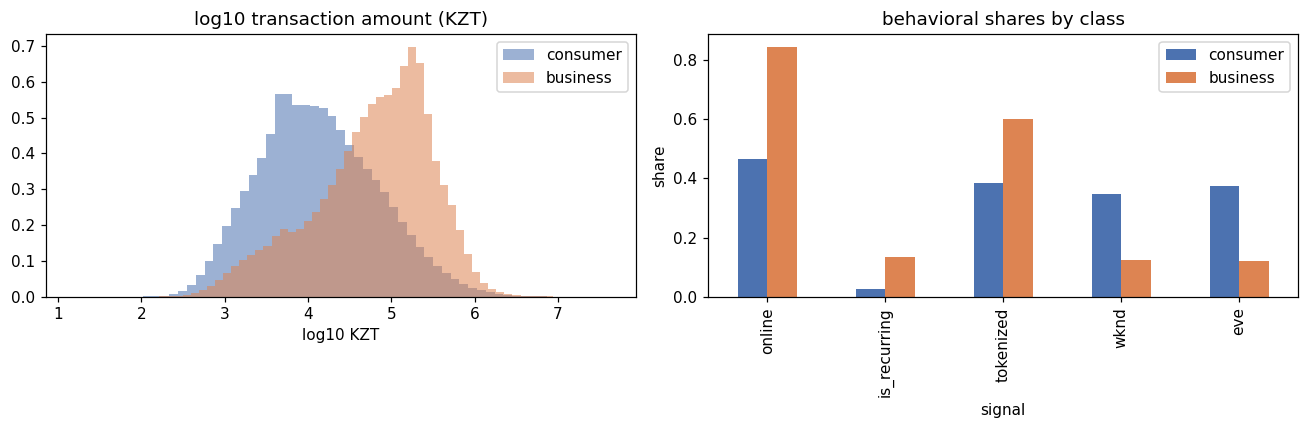

In [4]:
# behavioral share contrast (tx-level)
ts = pd.to_datetime(df["transaction_timestamp"])
contrast_src = df.assign(
    online=(df.channel=="online"), wknd=(ts.dt.dayofweek>=5), eve=ts.dt.hour.between(18,23))
rows = []
for col in ["online", "is_recurring", "tokenized", "wknd", "eve"]:
    s = contrast_src.groupby(LABEL_COL)[col].mean()
    rows.append((col, s[0], s[1]))
contrast = pd.DataFrame(rows, columns=["signal","consumer","business"]).set_index("signal")
display(contrast.round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for lab, name, c in [(0,"consumer","#4C72B0"), (1,"business","#DD8452")]:
    ax[0].hist(np.log10(df.loc[df.label==lab,"transaction_amount_kzt"].clip(lower=1)),
               bins=60, alpha=.55, label=name, color=c, density=True)
ax[0].set_title("log10 transaction amount (KZT)"); ax[0].set_xlabel("log10 KZT"); ax[0].legend()
contrast.plot.bar(ax=ax[1], color=["#4C72B0","#DD8452"]); ax[1].set_title("behavioral shares by class")
ax[1].set_ylabel("share"); plt.tight_layout(); plt.show()

## 03 · Leakage screen
Synthetic data often hides perfect separators. Policy: **flag and exclude**.

In [5]:
print("card_tier by class (perfect giveaway -> dropped):")
display(pd.crosstab(df.label, df.card_tier))

con_m, biz_m = df[df.label==0], df[df.label==1]
for col in ["mcc","merchant_id"]:
    cset, bset = set(con_m[col].unique()), set(biz_m[col].unique())
    only_b = bset - cset
    vol = biz_m[col].isin(only_b).mean()
    print(f"{col}: biz-only={len(only_b)}  con-only={len(cset-bset)}  shared={len(cset & bset)}  "
          f"| biz volume in biz-only {col}: {vol:.3%}  (artifact, so {col} is NOT one-hot encoded)")
print("\ndropped entirely:", LEAKY_OR_EXCLUDED, "| B2B basket size:", len(B2B_MCC), "(5122 removed: biz-exclusive)")

card_tier by class (perfect giveaway -> dropped):


card_tier,Affluent,Business,Premium,Standard
label,,,,
0,2061920,0,441717,7328850
1,0,2997593,0,0


mcc: biz-only=32  con-only=428  shared=72  | biz volume in biz-only mcc: 3.150%  (artifact, so mcc is NOT one-hot encoded)


merchant_id: biz-only=105  con-only=1684  shared=376  | biz volume in biz-only merchant_id: 3.150%  (artifact, so merchant_id is NOT one-hot encoded)

dropped entirely: ['card_tier', 'bank_name'] | B2B basket size: 43 (5122 removed: biz-exclusive)


## 04 · Feature engineering (card level)
`build_card_features` aggregates transactions → one row per card: amount stats, counts,
diversity/entropy, merchant concentration (HHI / top-ratio), recurring/tokenized/channel/
temporal shares, curated B2B exposure, B2B supplier breadth, monthly stability, burstiness,
recency. Redundant duplicates (mcc-level concentration, `night_share`, `gap_cv`, …) were
pruned in the audit. See `features.py`.

In [6]:
import os
feat = pd.read_parquet(FEAT_FILE) if os.path.exists(FEAT_FILE) else build_card_features(df)
FEATURES = [c for c in feat.columns if c not in (ID_COL, LABEL_COL)]
print("feature matrix:", feat.shape, "| n_features:", len(FEATURES),
      "| positive_rate:", round(feat[LABEL_COL].mean(), 4))
del df; gc.collect()                 # free the 12.8M-row frame; not needed past here
display(feat[FEATURES].head(3))

feature matrix: (105000, 37) | n_features: 35 | positive_rate: 0.2381


,tx_count,amt_sum,amt_mean,amt_median,amt_std,amt_max,amt_min,n_unique_merchants,n_unique_mcc,n_unique_countries,recurring_share,tokenized_share,online_share,weekend_share,evening_share,bizhours_share,foreign_share,b2b_mcc_share,recurring_capable_share,active_days,active_weeks,b2b_amt_share,amt_cv,span_days,tx_per_active_day,recency_days,merchants_per_tx,merchant_hhi,merchant_top_ratio,merchant_entropy,b2b_unique_merchants,monthly_spend_cv,gap_mean,gap_std,burstiness
0,178,9651486.0,54221.831461,14499.0,92378.778008,745914.0,659.0,9,9,9,0.067416,0.646067,0.865169,0.101124,0.151685,0.640449,0.196629,0.146067,0.140449,105,27,0.365837,1.703719,182,1.695238,0,0.050562,0.253566,0.432584,1.700050,4,0.229397,24.583851,28.329965,0.070797
1,106,14353608.0,135411.396226,67810.0,198947.026012,1483178.0,604.0,18,18,5,0.169811,0.632075,0.905660,0.122642,0.150943,0.613208,0.273585,0.584906,0.452830,80,27,0.854934,1.469204,182,1.325000,0,0.169811,0.187967,0.349057,2.119791,9,0.339206,41.292958,40.232464,-0.013008
2,148,13102356.0,88529.432432,56445.0,101798.906783,652796.0,262.0,8,8,3,0.040541,0.655405,0.891892,0.114865,0.101351,0.716216,0.195946,0.790541,0.067568,90,27,0.777215,1.149888,182,1.644444,0,0.054054,0.271366,0.466216,1.645914,6,0.171563,29.573228,33.904017,0.068226


In [7]:
# class-mean contrast (sanity: do features separate as expected?)
g = feat.groupby(LABEL_COL)[FEATURES].mean().T
g.columns = ["consumer","business"]; g["b/c_ratio"] = (g.business/g.consumer.replace(0,np.nan)).round(2)
display(g.round(3))

,consumer,business,b/c_ratio
tx_count,122.906,1.199040e+02,0.98
amt_sum,6642511.708,1.876916e+07,2.83
amt_mean,54770.136,1.676424e+05,3.06
amt_median,23119.451,9.222524e+04,3.99
amt_std,99972.460,2.301465e+05,2.30
amt_max,736432.469,1.494760e+06,2.03
amt_min,1095.117,1.810038e+03,1.65
n_unique_merchants,36.750,1.708700e+01,0.46
n_unique_mcc,31.683,1.484900e+01,0.47
n_unique_countries,9.048,5.740000e+00,0.63


### 04b · Univariate leakage re-check
No engineered feature should be a perfect (AUC=1.0) separator on its own — that would signal
residual leakage. The high-but-<1.0 AUCs below are legitimate behavioral signals; their
*cleanliness* is the synthetic-data caveat, not a leak.

max univariate AUC: 0.9948 (1.0 would mean a hard leak)


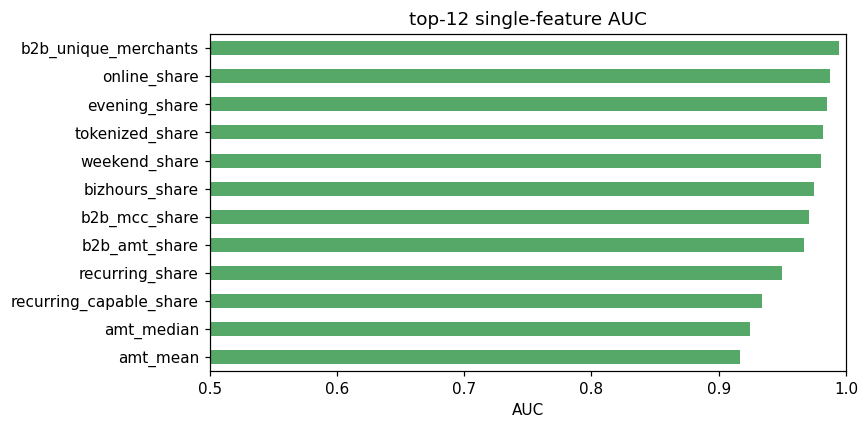

In [8]:
from sklearn.metrics import roc_auc_score
y_all = feat[LABEL_COL].values
uni = pd.Series({c: max((a:=roc_auc_score(y_all, feat[c])), 1-a) for c in FEATURES}).sort_values(ascending=False)
print("max univariate AUC:", round(uni.max(), 4), "(1.0 would mean a hard leak)")
uni.head(12).iloc[::-1].plot.barh(color="#55A868"); plt.title("top-12 single-feature AUC")
plt.xlabel("AUC"); plt.xlim(0.5, 1.0); plt.tight_layout(); plt.show()

## 05 · Stratified train / validation split
Split is on **cards**, so no card appears in both sets.

In [9]:
X, y = feat[FEATURES], feat[LABEL_COL].values
Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=SEED)
print("train", Xtr.shape, "| val", Xva.shape, "| val positive_rate", round(yva.mean(), 4))

train (84000, 35) | val (21000, 35) | val positive_rate 0.2381


## 06–07 · Models: LogReg (baseline) · LightGBM (main) · RandomForest (compare)
Preprocessing for LogReg (log1p + scaling) is fit **inside a Pipeline on train only**.

In [10]:
models = {"LogReg": make_logreg(FEATURES), "LightGBM": make_lgbm(), "RandomForest": make_rf()}
fitted, rows = {}, []
for name, m in models.items():
    m.fit(Xtr, ytr); p = m.predict_proba(Xva)[:,1]; fitted[name] = m
    rows.append({"model": name, **ranking_metrics(yva, p)})
display(pd.DataFrame(rows).set_index("model").round(4))
print("All models saturate (~1.0): consumer vs business is near-linearly separable in this "
      "synthetic data. LogReg's perfect score confirms the signal is clean & near-linear; we "
      "keep LightGBM as the main model for SHAP reason codes (RM outreach).")

,ROC_AUC,PR_AUC
model,,
LogReg,1.0,1.0
LightGBM,1.0,1.0
RandomForest,1.0,1.0


All models saturate (~1.0): consumer vs business is near-linearly separable in this synthetic data. LogReg's perfect score confirms the signal is clean & near-linear; we keep LightGBM as the main model for SHAP reason codes (RM outreach).


## 08 · Evaluation & threshold tuning (LightGBM)
Thresholds are tuned on **train out-of-fold** predictions (never the validation set), then
applied to validation. Two operating points: **recall-leaning** for outreach lists (a missed
SME is lost revenue; a false positive is a cheap call) and **F1-max** for auto-decisions.

VAL ranking: {'ROC_AUC': 1.0, 'PR_AUC': 1.0}


train-OOF thresholds -> F1-max=0.318 | recall>=0.95=0.982
[F1-max] thr=0.318  precision=1.0000 recall=0.9998 f1=0.9999
[recall>=0.95] thr=0.982  precision=1.0000 recall=0.9978 f1=0.9989


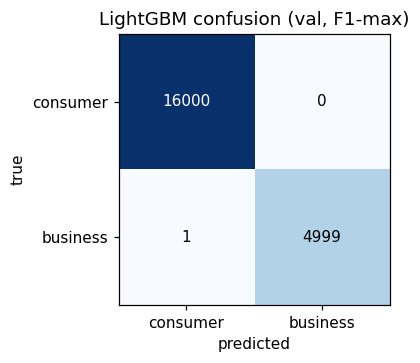

In [11]:
lgbm = fitted["LightGBM"]; pva = lgbm.predict_proba(Xva)[:,1]
print("VAL ranking:", {k: round(v,4) for k,v in ranking_metrics(yva, pva).items()})

thr = tune_thresholds(ytr, oof_proba(make_lgbm, Xtr, ytr))   # tuned on TRAIN OOF
print(f"train-OOF thresholds -> F1-max={thr['f1']:.3f} | recall>=0.95={thr['recall']:.3f}")

for name, t in [("F1-max", thr['f1']), ("recall>=0.95", thr['recall'])]:
    m = metrics_at_threshold(yva, pva, t)
    print(f"[{name}] thr={t:.3f}  precision={m['precision']:.4f} recall={m['recall']:.4f} f1={m['f1']:.4f}")

cm = metrics_at_threshold(yva, pva, thr['f1'])["confusion"]
fig, ax = plt.subplots(figsize=(4, 3.4)); plot_confusion(cm, ax, title="LightGBM confusion (val, F1-max)")
plt.tight_layout(); plt.show()

## 09 · Explainability (SHAP)
Global drivers + a per-customer reason code (what an RM would see).

C:\Users\olzha\OneDrive\Рабочий_стол\MDQ\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


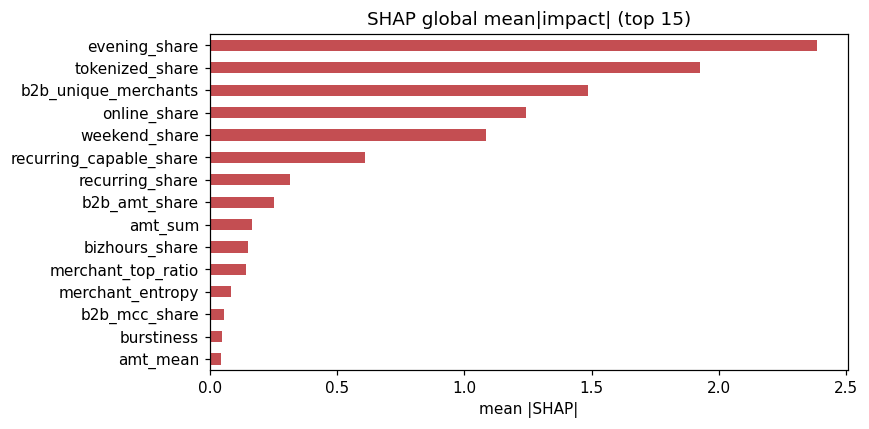

In [12]:
expl = shap.TreeExplainer(lgbm)
samp = X.sample(min(4000, len(X)), random_state=SEED)
glob = pd.Series(np.abs(shap_positive_values(expl, samp)).mean(0),
                 index=FEATURES).sort_values(ascending=False)
glob.head(15).iloc[::-1].plot.barh(color="#C44E52"); plt.title("SHAP global mean|impact| (top 15)")
plt.xlabel("mean |SHAP|"); plt.tight_layout(); plt.show()
# Optional beeswarm: shap.summary_plot(shap_positive_values(expl, samp), samp)

## 10 · Score consumers → hidden entrepreneurs
Out-of-fold `P(business)` for every card (each consumer scored by a model that did not train
on it). High-scoring consumers are the leads.

consumer OOF P(business) percentiles:
count    80000.0000
mean         0.0001
std          0.0081
min          0.0000
50%          0.0000
90%          0.0000
99%          0.0000
99.9%        0.0046
max          0.9923

consumers above threshold: {'P>=0.1': 22, 'P>=0.3': 11, 'P>=0.5': 5, 'P>=0.9': 2}


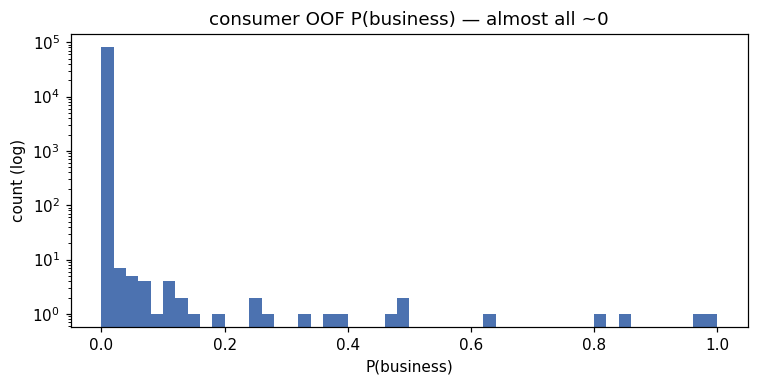

In [13]:
feat["oof_p"] = oof_proba(make_lgbm, X, y)
con = feat[feat.label==0].copy(); biz = feat[feat.label==1].copy()
print("consumer OOF P(business) percentiles:")
print(con.oof_p.describe(percentiles=[.5,.9,.99,.999]).round(4).to_string())
print("\nconsumers above threshold:", {f"P>={t}": int((con.oof_p>=t).sum()) for t in [0.1,0.3,0.5,0.9]})

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(con.oof_p, bins=np.linspace(0,1,51), color="#4C72B0"); ax.set_yscale("log")
ax.set_title("consumer OOF P(business) — almost all ~0"); ax.set_xlabel("P(business)")
ax.set_ylabel("count (log)"); plt.tight_layout(); plt.show()

In [14]:
leads = con[con.oof_p>=LEAD_THR].sort_values("oof_p", ascending=False)
if len(leads) < 10: leads = con.sort_values("oof_p", ascending=False).head(25)
cmp_cols = ["oof_p","amt_sum","amt_median","online_share","recurring_share","b2b_mcc_share",
            "b2b_amt_share","b2b_unique_merchants","recurring_capable_share","merchant_top_ratio"]
profile = pd.DataFrame({"typical_consumer":con[cmp_cols].median(),
                        "hidden_entrepreneur":leads[cmp_cols].median(),
                        "typical_business":biz[cmp_cols].median()})
print(f"{len(leads)} hidden-entrepreneur leads (P>={LEAD_THR}); profile vs baselines:")
display(profile.round(3))
leads[[ID_COL]+cmp_cols].to_csv("hidden_entrepreneurs.csv", index=False)
print("saved hidden_entrepreneurs.csv")

top = leads.iloc[[0]][FEATURES]
rc = pd.Series(shap_positive_values(expl, top)[0], index=FEATURES).sort_values(key=np.abs, ascending=False).head(8)
print(f"\nreason codes - card {leads.iloc[0][ID_COL]} (P={leads.iloc[0].oof_p:.3f}); +ve => business:")
print(rc.round(3).to_string())

11 hidden-entrepreneur leads (P>=0.3); profile vs baselines:


,typical_consumer,hidden_entrepreneur,typical_business
oof_p,0.000,4.990000e-01,1.000000e+00
amt_sum,2976294.000,1.607314e+07,1.771489e+07
amt_median,9673.500,1.700600e+05,8.455850e+04
online_share,0.447,8.540000e-01,8.520000e-01
recurring_share,0.000,2.310000e-01,1.340000e-01
b2b_mcc_share,0.016,6.570000e-01,6.180000e-01
b2b_amt_share,0.015,8.890000e-01,8.090000e-01
b2b_unique_merchants,1.000,3.000000e+00,7.000000e+00
recurring_capable_share,0.032,4.230000e-01,2.940000e-01
merchant_top_ratio,0.111,4.160000e-01,3.710000e-01


saved hidden_entrepreneurs.csv

reason codes - card 5201491354169846 (P=0.992); +ve => business:
evening_share              4.142
tokenized_share           -3.986
b2b_unique_merchants      -3.323
online_share               2.221
weekend_share              1.669
recurring_share            1.169
recurring_capable_share    0.920
merchant_top_ratio         0.484


C:\Users\olzha\OneDrive\Рабочий_стол\MDQ\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## 11 · Business recommendations

**Business signature the model learned:** high **online** share, **business-hours** activity
(low weekend/evening), high **recurring** share (payroll/subscriptions), broad **B2B supplier**
base, larger tickets, and spend concentrated on few merchants (high HHI / top-merchant ratio).

**Action — for the surfaced leads (`hidden_entrepreneurs.csv`):**
- **Tariff migration** — spend profile (median ~170K KZT/tx, ~89% B2B amount share) is SME-like.
- **POS acquiring** — high online + merchant concentration → likely selling.
- **Working-capital loan** — recurring outflows to multiple B2B suppliers → financing fit.
- **Payroll & cash management** — recurring-payment cadence suggests staff/supplier payments.
- **Bookkeeping** — diverse B2B spend → value in automated reconciliation.

**Operating point:** recall-leaning threshold for outreach lists (cheap false positives), F1-max
for auto-migration. Hand RMs the SHAP reason codes per lead for specific, credible outreach.

## 12 · Methodology summary (notebook-ready)

1. **Unit & label.** One row per `card_number`; `business=1`, `consumer=0`. ~105k cards, 23.8% positive.
2. **Features (35).** Card-level aggregates only — amount shape, counts, merchant diversity/
   concentration (HHI, entropy, top-ratio), recurring/tokenized/channel/temporal shares, curated
   B2B count & amount share, B2B supplier breadth, recurring-capable-merchant share, monthly-spend
   stability, inter-arrival burstiness, recency.
3. **Leakage control.** Dropped `card_tier` (perfect) and `bank_name` (no signal); no raw
   `mcc`/`merchant_id` one-hot (exclusivity is a coverage artifact); removed `5122` from the B2B
   basket; pruned redundant duplicates (|r|>0.97) and near-random features.
4. **Validation.** Stratified 80/20 split on cards; thresholds tuned on train out-of-fold;
   consumers scored out-of-fold so each is judged by a model that never saw it.
5. **Models.** LogReg (baseline) ≈ LightGBM (main) ≈ RF, all ROC-AUC≈1.0; LightGBM kept for SHAP.
6. **Why random (not chronological) split.** The label is an intrinsic card type observed over a
   fixed 6-month window, not a future event; every card spans the same window and `recency_days`
   is measured from one global cutoff — so there is no temporal target to leak. A chronological
   split would be required only to predict "becomes a business next quarter."

## 13 · Why this is trustworthy (presentation-ready)

- **Leakage handled, not hidden.** The one perfect giveaway (`card_tier`) and a business-exclusive
  MCC (`5122`) were removed; we verified **no remaining feature separates the classes alone**
  (max univariate AUC < 1.0). Identifiers (`mcc`, `merchant_id`) are never used as raw features.
- **Honest validation.** Split on cards (no overlap), preprocessing fit on train only, thresholds
  tuned on out-of-fold data, consumers scored out-of-fold. So the ~1.0 metric is not from peeking.
- **The model is explainable & robust.** A linear baseline matches the boosted model → the signal
  is genuine and near-linear, **not** tree overfitting. SHAP gives per-customer reason codes.
- **Right metric, right threshold.** We report PR-AUC and confusion matrices, and choose a
  **recall-leaning** threshold for outreach (a missed SME costs far more than a cheap call) and
  **F1-max** for automated migration.
- **Stated limitation.** ROC-AUC≈1.0 reflects clean synthetic separation and will **not** transfer
  to production unchanged — re-baseline and recalibrate on real labeled cards before trusting any
  threshold. The pipeline (features + OOF scoring + reason codes) is what transfers.